# Business Understanding

## Business Problem

The company invests in multiple marketing channels, including Search, Display, Social, Email, and Influencer campaigns. Although these campaigns generate impressions, clicks, leads, and conversions, management lacks clear insights into which marketing channels deliver the best financial return and which campaigns should receive a larger share of the marketing budget. The objective of this project is to evaluate campaign performance using key marketing KPIs and provide data-driven recommendations to optimize future marketing investments.

## Business Objectives



*   Analyze the performance of marketing campaigns across different channels.
*   Evaluate campaign efficiency using marketing KPIs.
*   Identify the most profitable marketing channels.
*   Examine relationships between campaign metrics and financial outcomes.
*  Provide actionable recommendations for optimizing marketing investment.



## Business Questions

1. Which marketing channel generates the highest revenue?
2. Which marketing channel produces the highest ROI?
3. Which marketing channel generates the highest profit?
4. Which channel achieves the highest Click-Through Rate (CTR)?
5. Which channel converts leads into customers most effectively?
6. Which channel has the lowest Customer Acquisition Cost (CPA)?
7. Which marketing channel has the highest ROAS?
8. Does higher campaign spending lead to higher revenue?
9. Does higher spending always produce higher ROI?
10. Does campaign duration affect campaign performance?
11. Do more leads result in more conversions?
12. Do more clicks generate more leads?
13. Which marketing KPIs have the strongest relationship with revenue and ROI?

# Data Understanding

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

path = kagglehub.dataset_download("mirzayasirabdullah07/marketing-campaign-performance-dataset")
print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 287k/287k [00:00<00:00, 74.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mirzayasirabdullah07/marketing-campaign-performance-dataset/versions/1
['marketing_campaign_performance_10000.csv']


In [ ]:
file_path = os.path.join(path, "marketing_campaign_performance_10000.csv")
df = pd.read_csv(file_path)

In [ ]:
df.shape

(10000, 11)

In [ ]:
df.head(10)

,CampaignID,StartDate,EndDate,Channel,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
0,CAMP00001,2025-04-13,2025-04-19,Search,293520,23335,11643,5389,1052.39,2236.02,1.12
1,CAMP00002,2025-12-15,2025-12-24,Search,200340,15841,6601,2498,3964.90,11740.15,1.96
2,CAMP00003,2025-09-28,2025-10-06,Email,239365,16478,8043,3397,1000.39,1902.24,0.90
3,CAMP00004,2025-04-17,2025-04-30,Search,156382,2672,1014,342,1252.63,2209.74,0.76
4,CAMP00005,2025-03-13,2025-03-22,Influencer,285472,4155,1521,565,4935.48,14111.31,1.86
5,CAMP00006,2025-07-08,2025-07-21,Social,177469,7979,3231,1446,3540.34,3885.94,0.10
6,CAMP00007,2025-01-21,2025-02-05,Display,174231,2160,379,107,1999.53,3306.37,0.65
7,CAMP00008,2025-04-13,2025-04-26,Display,234598,21435,9052,2295,3793.91,7159.09,0.89
8,CAMP00009,2025-05-02,2025-05-08,Influencer,209438,2474,1207,697,2385.72,2800.53,0.17
9,CAMP00010,2025-08-03,2025-08-16,Search,195376,2474,852,251,1142.07,2323.19,1.03


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CampaignID   10000 non-null  object 
 1   StartDate    10000 non-null  object 
 2   EndDate      10000 non-null  object 
 3   Channel      10000 non-null  object 
 4   Impressions  10000 non-null  int64  
 5   Clicks       10000 non-null  int64  
 6   Leads        10000 non-null  int64  
 7   Conversions  10000 non-null  int64  
 8   Cost_USD     10000 non-null  float64
 9   Revenue_USD  10000 non-null  float64
 10  ROI          10000 non-null  float64
dtypes: float64(3), int64(4), object(4)
memory usage: 859.5+ KB


In [ ]:
df.describe()

,Impressions,Clicks,Leads,Conversions,Cost_USD,Revenue_USD,ROI
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,152260.637900,8338.993300,2512.463600,1010.700000,2552.356991,5102.648930,1.001576
std,85251.707621,6546.326431,2321.031302,1019.402613,1427.694545,3309.326705,0.578806
min,5043.000000,72.000000,10.000000,4.000000,100.230000,113.640000,0.000000
25%,78956.000000,2981.000000,779.000000,295.000000,1319.622500,2385.742500,0.500000
50%,151505.500000,6588.500000,1777.000000,670.000000,2529.675000,4659.365000,0.990000
75%,225853.250000,12404.250000,3550.250000,1391.000000,3821.307500,7241.245000,1.510000
max,299997.000000,29578.000000,13833.000000,7987.000000,4998.420000,14871.340000,2.000000


# Data Cleaning

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['StartDate'] = pd.to_datetime(df['StartDate'])
df['EndDate'] = pd.to_datetime(df['EndDate'])

In [ ]:
numeric_cols = ["Impressions", "Clicks", "Leads", "Conversions", "Cost_USD", "Revenue_USD", "ROI"]
(df[numeric_cols] < 0).sum()

,0
Impressions,0
Clicks,0
Leads,0
Conversions,0
Cost_USD,0
Revenue_USD,0
ROI,0


In [ ]:
invalid_clicks = df[df["Clicks"] > df["Impressions"]]
print("Invalid Clicks:", len(invalid_clicks))

invalid_leads = df[df["Leads"] > df["Clicks"]]
print("Invalid Leads:", len(invalid_leads))

invalid_conversions = df[df["Conversions"] > df["Leads"]]
print("Invalid Conversions:", len(invalid_conversions))

Invalid Clicks: 0
Invalid Leads: 0
Invalid Conversions: 0


In [ ]:
df["ROI"] = ((df["Revenue_USD"] - df["Cost_USD"]) / df["Cost_USD"]) * 100
df["ROI"]

,ROI
0,112.470662
1,196.102045
2,90.149842
3,76.408037
4,185.915656
...,...
9995,176.438094
9996,59.350266
9997,190.243067
9998,128.094974


In [ ]:
Calculated_ROI = ((df["Revenue_USD"] - df["Cost_USD"]) / df["Cost_USD"]) * 100
roi_difference = (Calculated_ROI - df["ROI"]).abs()
roi_difference.describe()

,0
count,10000.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


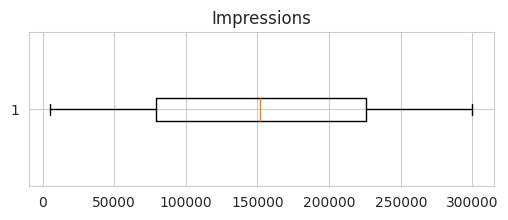

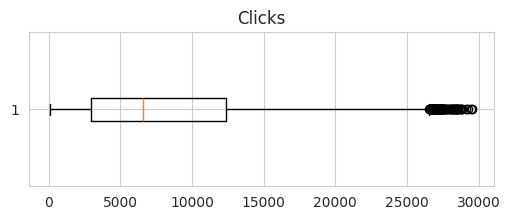

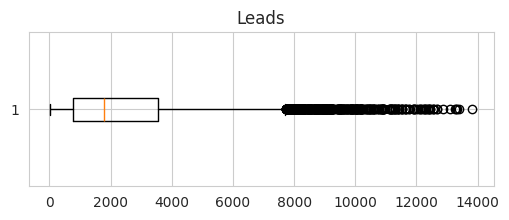

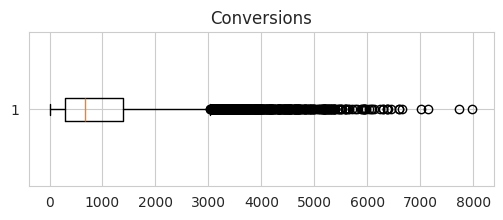

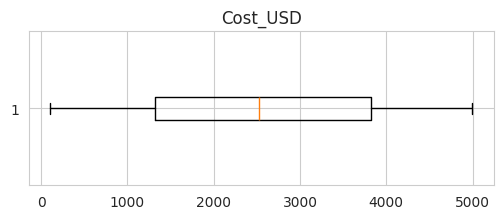

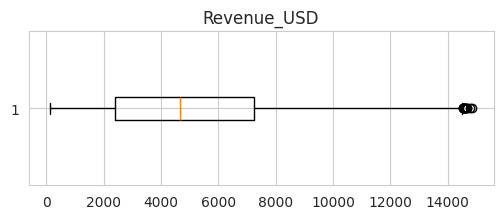

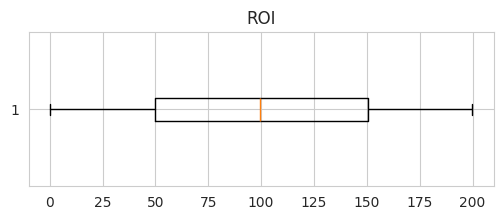

In [ ]:
import matplotlib.pyplot as plt

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

# Feature Engineering

In [ ]:
df["Campaign_Duration"] = (df["EndDate"] - df["StartDate"]).dt.days
df["Start_Month"] = df["StartDate"].dt.month
df["Start_Day"] = df["StartDate"].dt.day
df["Start_Year"] = df["StartDate"].dt.year

In [ ]:
df["CTR"] = df["Clicks"]/df["Impressions"]
df["CPC"] = df["Cost_USD"]/df["Clicks"]
df["CPL"] = df["Cost_USD"]/df["Leads"]
df["CPA"] = df["Cost_USD"]/df["Conversions"]
df["Leads_Rate"] = df["Leads"]/df["Clicks"]
df["Conversion_Rate"] = df["Conversions"]/df["Leads"]
df["Profit"] = df["Revenue_USD"] - df["Cost_USD"]
df["ROAS"] = df["Revenue_USD"]/df["Cost_USD"]

# EDA

## Univariate Analysis

### Sumary Statistics

In [ ]:
numerical_cols = ['Impressions', 'Clicks', 'Leads', 'Conversions', 'Cost_USD', 'Revenue_USD', 'ROI', 'Campaign_Duration', 'CTR', 'CPC', 'CPL', 'CPA', 'Leads_Rate', 'Conversion_Rate', 'Profit', 'ROAS']
categorical_cols = ['Channel']

summary = df[numerical_cols].describe().T
summary["median"] = df[numerical_cols].median()
summary["skewness"] = df[numerical_cols].skew()
summary["kurtosis"] = df[numerical_cols].kurt()
summary

,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis
Impressions,10000.0,152260.637900,85251.707621,5043.000000,78956.000000,151505.500000,225853.250000,299997.000000,151505.500000,0.001012,-1.202222
Clicks,10000.0,8338.993300,6546.326431,72.000000,2981.000000,6588.500000,12404.250000,29578.000000,6588.500000,0.902691,0.044806
Leads,10000.0,2512.463600,2321.031302,10.000000,779.000000,1777.000000,3550.250000,13833.000000,1777.000000,1.479028,2.146667
Conversions,10000.0,1010.700000,1019.402613,4.000000,295.000000,670.000000,1391.000000,7987.000000,670.000000,1.897420,4.444349
Cost_USD,10000.0,2552.356991,1427.694545,100.230000,1319.622500,2529.675000,3821.307500,4998.420000,2529.675000,0.014227,-1.214297
Revenue_USD,10000.0,5102.648930,3309.326705,113.640000,2385.742500,4659.365000,7241.245000,14871.340000,4659.365000,0.584817,-0.388373
ROI,10000.0,100.151852,57.880122,0.034878,49.969870,99.257015,150.545142,199.978711,99.257015,0.007011,-1.205044
Campaign_Duration,10000.0,9.962900,3.157106,5.000000,7.000000,10.000000,13.000000,15.000000,10.000000,0.004024,-1.222530
CTR,10000.0,0.054622,0.026018,0.010001,0.032404,0.054410,0.077079,0.099990,0.054410,0.029308,-1.191089
CPC,10000.0,0.920619,2.206758,0.003864,0.155262,0.339828,0.823086,57.099028,0.339828,9.555895,147.777265


Key Insight

The summary statistics provide an overview of the numerical variables. Several variables exhibit right-skewed distributions, indicating that while most campaigns perform around the average, a small number of campaigns achieve substantially higher performance.

### Marketing Channel Distribution

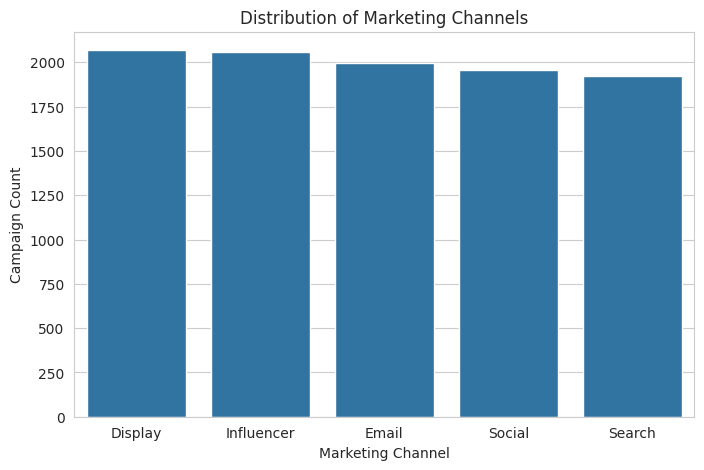

In [ ]:
channel_dist = (df["Channel"].value_counts().reset_index())
channel_dist.columns = ["Channel","Campaign_Count"]

plt.figure(figsize=(8,5))
sns.barplot(data=channel_dist, x="Channel", y="Campaign_Count", order=channel_dist.sort_values("Campaign_Count", ascending=False)["Channel"])
plt.title("Distribution of Marketing Channels")
plt.xlabel("Marketing Channel")
plt.ylabel("Campaign Count")
plt.show()

Insight

The campaigns are distributed across five marketing channels. A relatively balanced distribution indicates that channel performance comparisons are unlikely to be biased by a large difference in campaign volume.

#### Campaign Duration Distribution

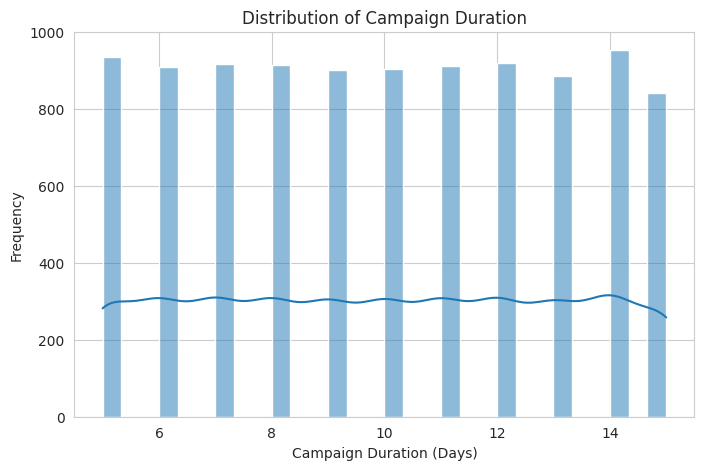

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Campaign_Duration"],
    bins=30,
    kde=True
)

plt.title("Distribution of Campaign Duration")
plt.xlabel("Campaign Duration (Days)")
plt.ylabel("Frequency")

plt.show()

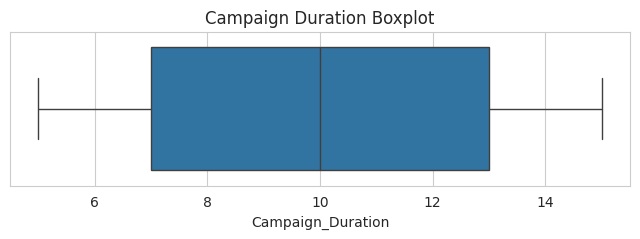

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["Campaign_Duration"]
)

plt.title("Campaign Duration Boxplot")

plt.show()

Insight

Campaign durations vary considerably, indicating that marketing strategies range from short-term promotions to long-running campaigns.

#### Revenue Distribution

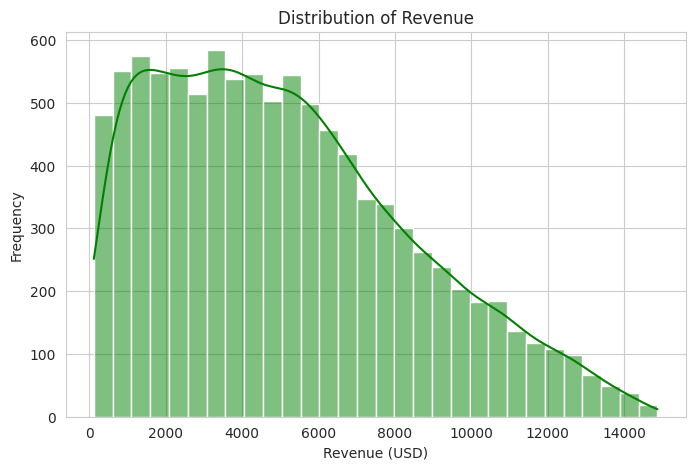

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Revenue_USD"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Distribution of Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Frequency")

plt.show()

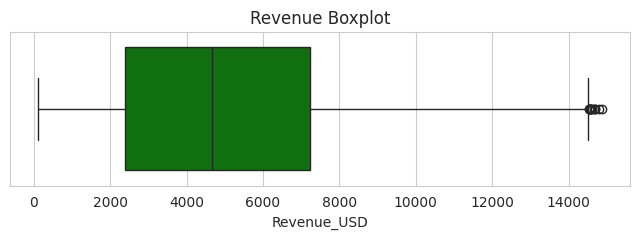

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["Revenue_USD"],
    color="green"
)

plt.title("Revenue Boxplot")

plt.show()

Insight

Revenue is positively skewed, suggesting that while most campaigns generate moderate revenue, a small number of campaigns deliver exceptionally high returns.

#### Campaign Cost Distribution

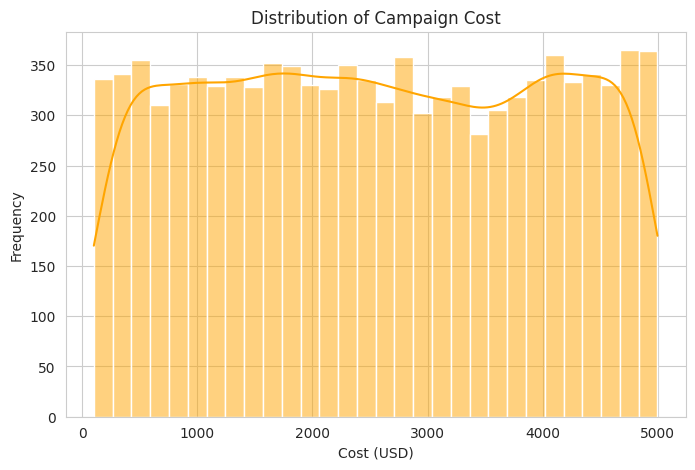

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Cost_USD"],
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Distribution of Campaign Cost")
plt.xlabel("Cost (USD)")
plt.ylabel("Frequency")

plt.show()

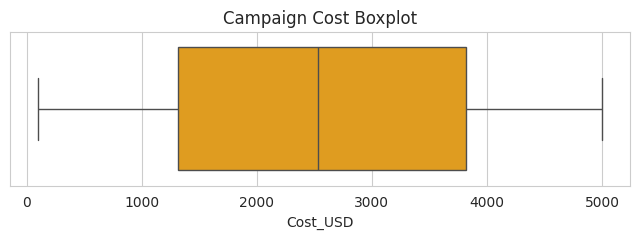

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["Cost_USD"],
    color="orange"
)

plt.title("Campaign Cost Boxplot")

plt.show()

Insight

Campaign costs are concentrated within a moderate range, although several campaigns require substantially higher investment than the majority.

#### ROI Distribution

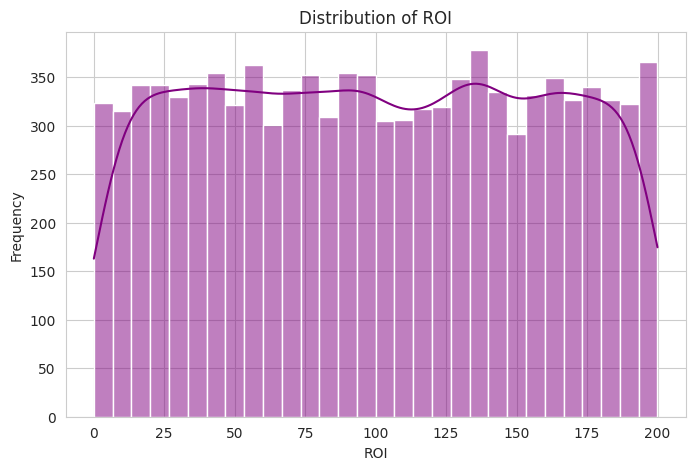

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["ROI"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Distribution of ROI")
plt.xlabel("ROI")
plt.ylabel("Frequency")

plt.show()

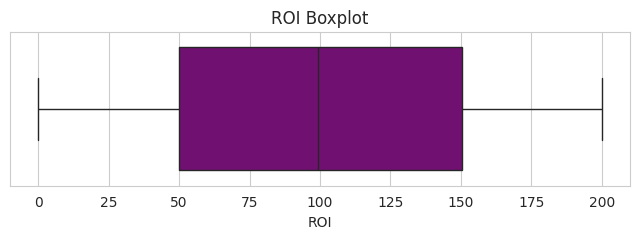

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["ROI"],
    color="purple"
)

plt.title("ROI Boxplot")

plt.show()

Insight

Most campaigns achieve positive ROI, indicating that marketing investments generally generate returns above their associated costs.

#### Profit Distribution

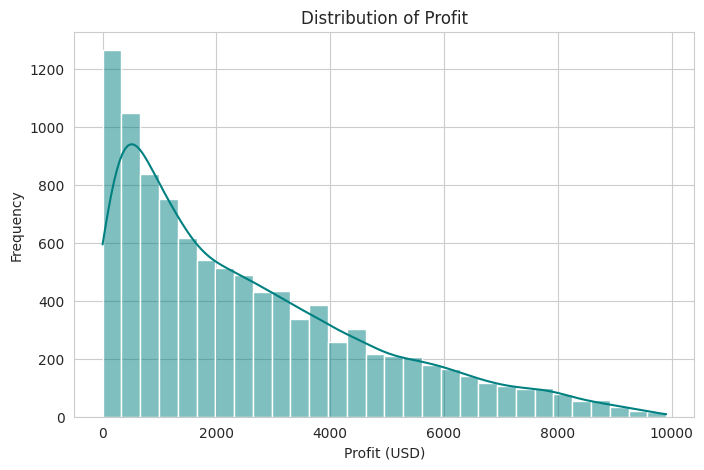

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Profit"],
    bins=30,
    kde=True,
    color="teal"
)

plt.title("Distribution of Profit")
plt.xlabel("Profit (USD)")
plt.ylabel("Frequency")

plt.show()

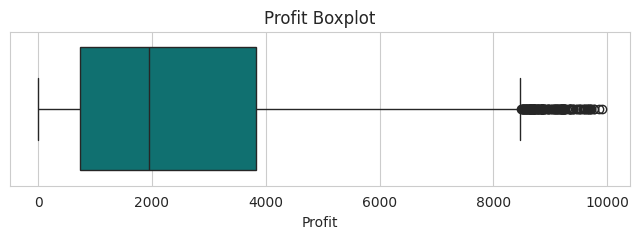

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["Profit"],
    color="teal"
)

plt.title("Profit Boxplot")

plt.show()

Insight

The profit distribution indicates that most campaigns are profitable, although a relatively small number of campaigns contribute disproportionately to total profit.

####ROAS Distribution


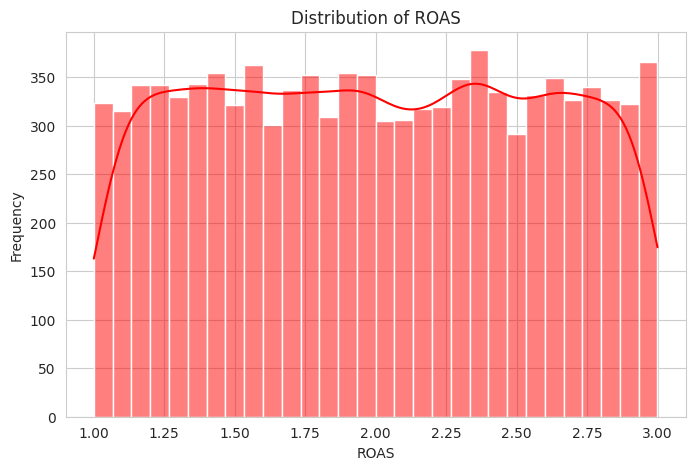

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["ROAS"],
    bins=30,
    kde=True,
    color="red"
)

plt.title("Distribution of ROAS")
plt.xlabel("ROAS")
plt.ylabel("Frequency")

plt.show()

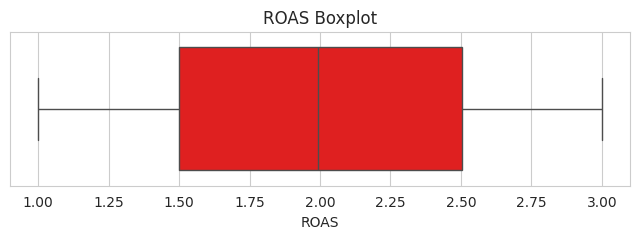

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["ROAS"],
    color="red"
)

plt.title("ROAS Boxplot")

plt.show()

Insight

ROAS values vary across campaigns, suggesting differences in how effectively marketing investments translate into revenue generation.

#### Marketing Funnel Metrics

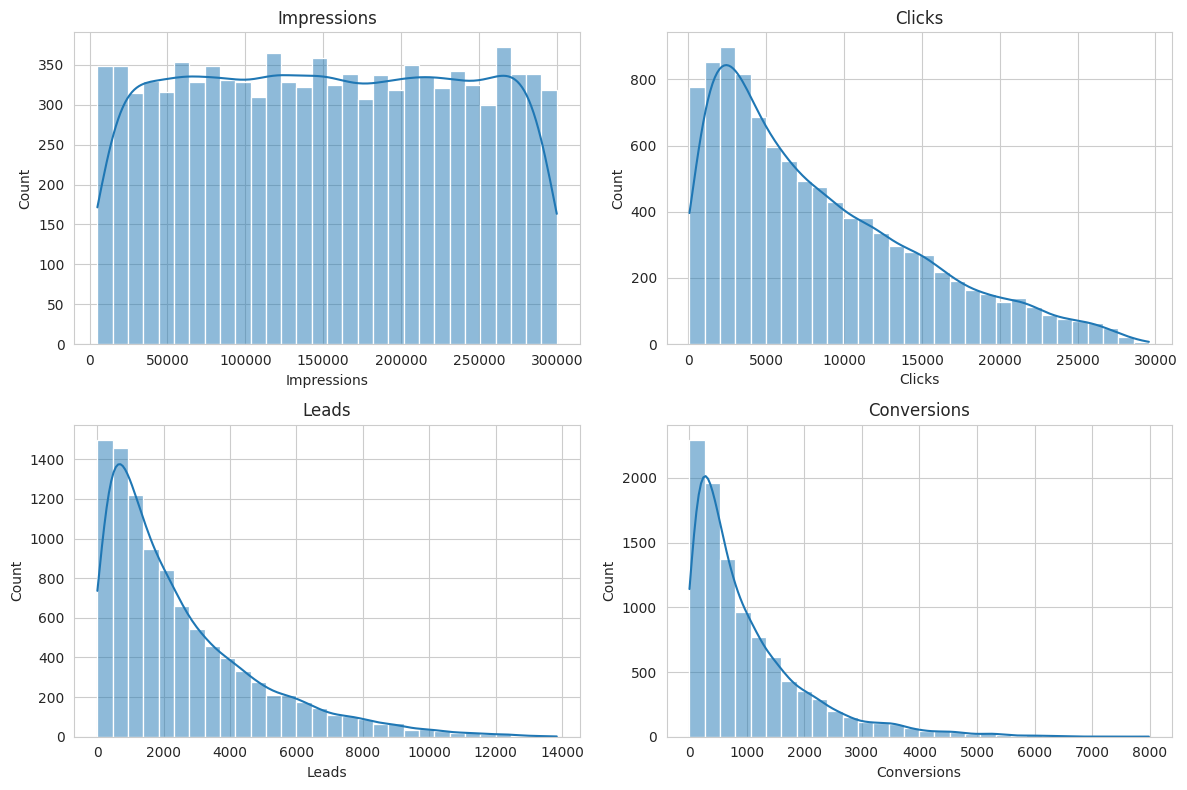

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

metrics = [
    ("Impressions", axes[0,0]),
    ("Clicks", axes[0,1]),
    ("Leads", axes[1,0]),
    ("Conversions", axes[1,1])
]

for col, ax in metrics:

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()

plt.show()

Insight

The marketing funnel metrics show a gradual reduction from impressions to conversions, reflecting the expected progression of customer engagement throughout the marketing funnel.

## Bivariate Analysis

### Which marketing channel generates the highest average revenue?

In [ ]:
revenue_channel = (df.groupby("Channel").agg(Average_Revenue=("Revenue_USD", "mean"), Total_Revenue=("Revenue_USD", "sum"), Campaigns=("CampaignID", "count")).sort_values("Average_Revenue", ascending=False))
revenue_channel

,Average_Revenue,Total_Revenue,Campaigns
Channel,,,
Display,5178.890870,10715125.21,2069
Search,5144.323176,9897677.79,1924
Influencer,5135.271882,10558118.99,2056
Email,5075.422149,10130542.61,1996
Social,4974.437187,9725024.70,1955


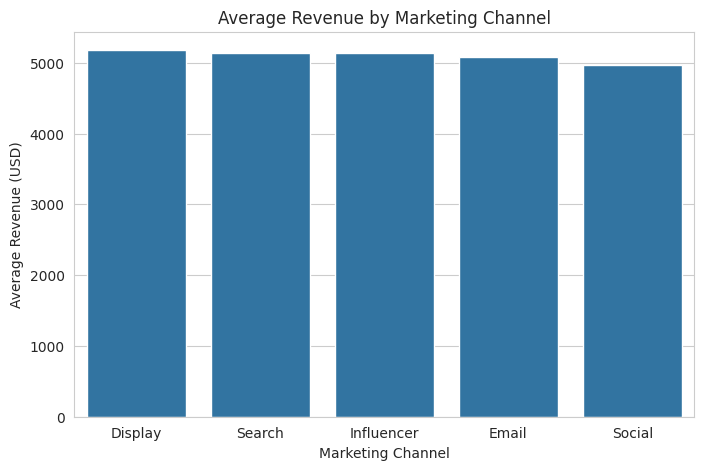

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=revenue_channel.reset_index(),
    x="Channel",
    y="Average_Revenue"
)

plt.title("Average Revenue by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Average Revenue (USD)")

plt.show()

Insight

Display campaigns generated the highest average revenue, indicating that display marketing is the most effective revenue-generating channel among the five channels.

Recomendation

Increase investment in high-performing channels while investigating the strategies that contribute to their superior performance.

### Which marketing channel achieves the highest ROI?

In [ ]:
roi_channel = (df.groupby("Channel").agg(Average_ROI=("ROI","mean")).sort_values("Average_ROI", ascending=False))
roi_channel

,Average_ROI
Channel,
Search,101.330737
Email,100.996132
Display,99.947846
Influencer,99.736693
Social,98.782186


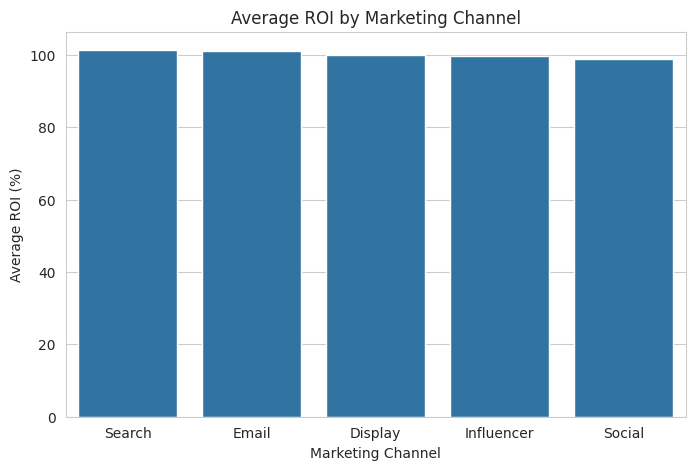

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=roi_channel.reset_index(),
    x="Channel",
    y="Average_ROI"
)

plt.title("Average ROI by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Average ROI (%)")

plt.show()

Insight

Search achieved the highest average ROI (101.33%), followed closely by Email (101.00%), while Social recorded the lowest average ROI (98.78%). The relatively narrow range of ROI values indicates that all marketing channels deliver comparable returns on investment, with Search showing a slight advantage in investment efficiency.

Impact

The consistently positive ROI across all channels suggests that marketing investments are generally profitable. However, Search campaigns appear to convert marketing spending into profit slightly more efficiently than the other channels.

Recommendation

Continue investing in Search campaigns while monitoring ROI trends over time. Instead of reducing budgets for lower-performing channels, focus on optimizing campaign execution, audience targeting, and creative performance to improve overall investment efficiency.

### Which marketing channel has the highest ROAS?

In [ ]:
roas_channel = (df.groupby("Channel").agg(Average_ROAS=("ROAS","mean")).sort_values("Average_ROAS", ascending=False))
roas_channel

,Average_ROAS
Channel,
Search,2.013307
Email,2.009961
Display,1.999478
Influencer,1.997367
Social,1.987822


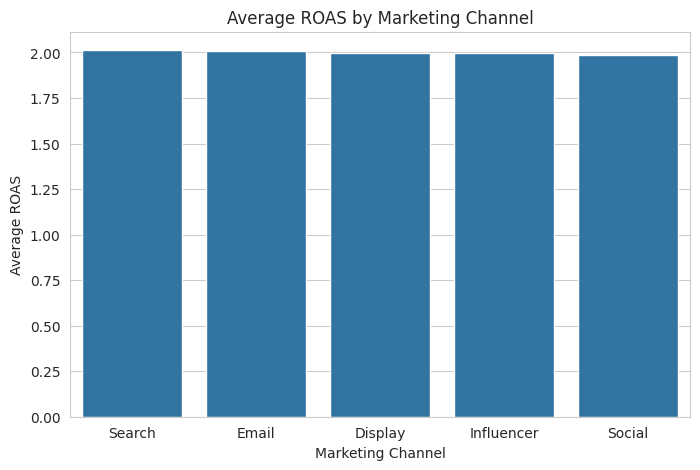

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=roas_channel.reset_index(),
    x="Channel",
    y="Average_ROAS"
)

plt.title("Average ROAS by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Average ROAS")

plt.show()

Insight

Search recorded the highest average ROAS (2.01), meaning that every USD 1 invested generated approximately USD 2.01 in revenue. Although Search outperformed the other channels, the ROAS values across all channels remain very similar, indicating consistent advertising efficiency throughout the marketing mix.

Impact

The relatively stable ROAS suggests that each marketing channel contributes effectively to revenue generation. Small performance differences indicate that campaign execution may have a greater influence on revenue than channel selection alone.

Recommendation

Maintain a diversified marketing strategy while prioritizing optimization within each channel. Future analysis should focus on identifying high-performing campaign characteristics rather than assuming one channel consistently outperforms the others.

### Which marketing channel has the lowest CPA?

In [ ]:
cpa_channel = (df.groupby("Channel").agg(Average_CPA=("CPA","mean")).sort_values("Average_CPA"))
cpa_channel

,Average_CPA
Channel,
Influencer,9.111069
Email,10.130729
Social,10.333181
Display,10.804092
Search,10.894869


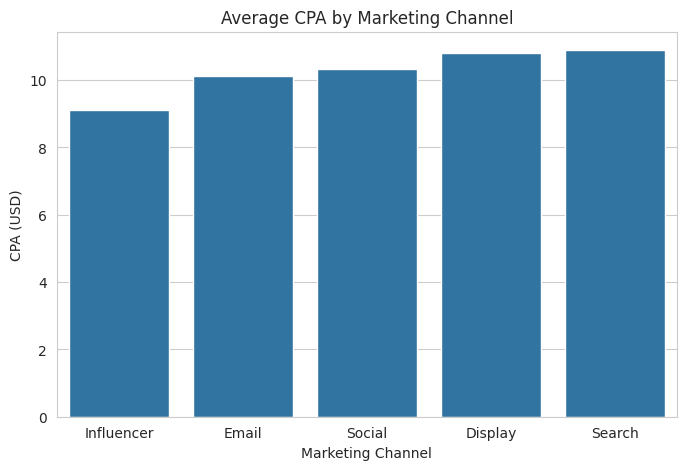

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=cpa_channel.reset_index(),
    x="Channel",
    y="Average_CPA"
)

plt.title("Average CPA by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("CPA (USD)")

plt.show()

Insight

Influencer campaigns achieved the lowest average Cost per Acquisition (USD 9.11), making them the most cost-efficient channel for acquiring customers. In contrast, Search recorded the highest average CPA (USD 10.89). Nevertheless, the overall variation in CPA across channels remains relatively small, indicating comparable customer acquisition costs.

Impact

Lower CPA allows the business to acquire customers more efficiently, potentially improving marketing profitability when conversion quality remains consistent. Influencer campaigns demonstrate stronger cost efficiency without substantially increasing acquisition expenses.

Recommendation

Explore opportunities to expand successful Influencer campaigns while evaluating whether the acquired customers maintain similar conversion quality and lifetime value. Customer acquisition decisions should balance acquisition cost with long-term business value rather than focusing solely on minimizing CPA.

### Which marketing channel generates the highest profit?

In [ ]:
profit_channel = (
    df.groupby("Channel")
    .agg(Average_Profit=("Profit", "mean"), Total_Profit=("Profit", "sum"))
    .sort_values("Average_Profit", ascending=False)
)
profit_channel

,Average_Profit,Total_Profit
Channel,,
Display,2596.394833,5371940.91
Search,2588.934163,4981109.33
Influencer,2567.768030,5279331.07
Email,2537.831979,5065512.63
Social,2457.813529,4805025.45


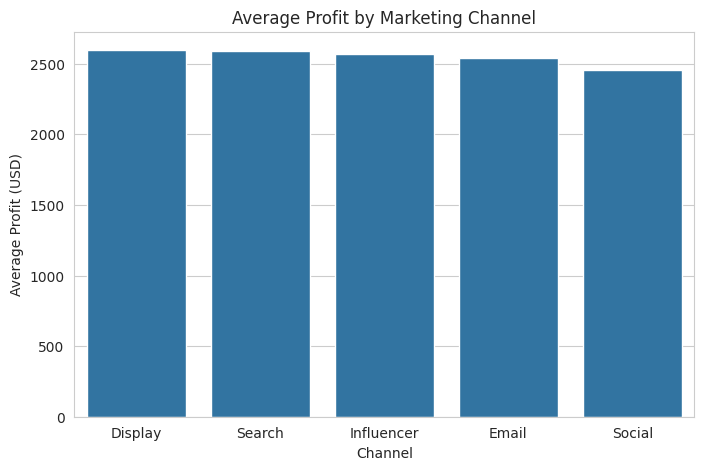

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=profit_channel.reset_index(),
    x="Channel",
    y="Average_Profit"
)

plt.title("Average Profit by Marketing Channel")
plt.xlabel("Channel")
plt.ylabel("Average Profit (USD)")

plt.show()

Insight

Display campaigns generate the highest average profit (USD 2,596.39), followed
closely by Search (USD 2,588.93) and Influencer (USD 2,567.77). The gap between
the top three channels is relatively small (less than USD 30 per campaign),
while Social records the lowest average profit (USD 2,457.81).

Impact

This confirms that Display's revenue advantage (seen earlier) translates into
an actual profit advantage, not just higher spending. However, because Search
and Influencer are close behind Display in profit despite different cost
structures, channel selection alone does not fully explain profitability —
campaign efficiency likely plays a comparable role.

Recommendation

Prioritize budget allocation toward Display, Search, and Influencer, which
form a closely-performing top tier in profitability. Investigate why Social
lags behind before deciding whether to reduce its budget or improve its
campaign execution.

### Which channel achieves the highest Click-Through Rate (CTR)?

In [ ]:
ctr_channel = (
    df.groupby("Channel")
    .agg(Average_CTR=("CTR", "mean"))
    .sort_values("Average_CTR", ascending=False)
)
ctr_channel

,Average_CTR
Channel,
Search,0.055169
Influencer,0.054669
Email,0.054562
Social,0.054429
Display,0.054306


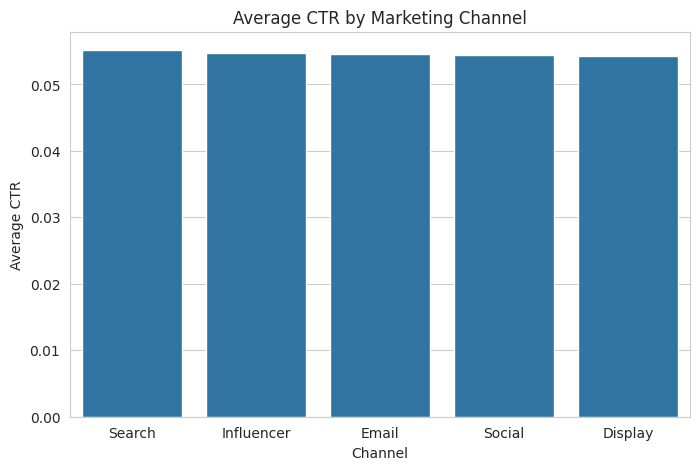

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=ctr_channel.reset_index(),
    x="Channel",
    y="Average_CTR"
)

plt.title("Average CTR by Marketing Channel")
plt.xlabel("Channel")
plt.ylabel("Average CTR")

plt.show()

Insight

CTR values are highly uniform across all channels, ranging narrowly from
5.43% (Display) to 5.52% (Search) — a spread of just 0.09 percentage points.
Search leads marginally, but the difference is too small to be practically
meaningful.

Impact

Click-through behavior does not meaningfully differentiate one channel from
another. Unlike Revenue or Profit, CTR is not a useful metric for deciding
where to allocate budget, since all channels perform almost identically at
this stage of the funnel.

Recommendation

Do not use CTR as a channel prioritization metric. Focus channel-level
budget decisions on downstream metrics that show meaningful variation, such
as Revenue, Profit, and CPA.

### Which channel converts leads into customers most effectively?

In [ ]:
conversion_channel = (
    df.groupby("Channel")
    .agg(Average_Conversion_Rate=("Conversion_Rate", "mean"))
    .sort_values("Average_Conversion_Rate", ascending=False)
)
conversion_channel

,Average_Conversion_Rate
Channel,
Social,0.402769
Display,0.402241
Influencer,0.401870
Search,0.401044
Email,0.400861


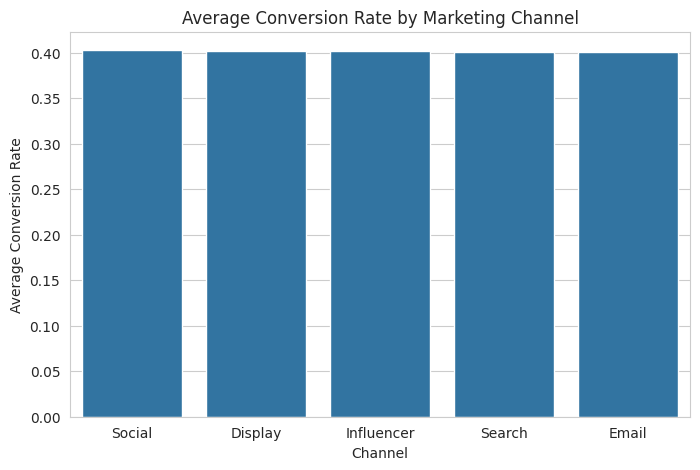

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=conversion_channel.reset_index(),
    x="Channel",
    y="Average_Conversion_Rate"
)

plt.title("Average Conversion Rate by Marketing Channel")
plt.xlabel("Channel")
plt.ylabel("Average Conversion Rate")

plt.show()

Insight

Conversion rates are also nearly identical across channels, ranging from
40.09% (Email) to 40.28% (Social) — a spread of only 0.19 percentage points.
Social converts leads into customers marginally more effectively, but again
the difference is negligible.

Impact

Similar to CTR, lead-to-conversion effectiveness does not vary meaningfully
by channel. This suggests conversion quality is likely driven by factors
outside the channel itself — such as lead quality, offer relevance, or sales
follow-up — rather than which platform the lead originated from.

Recommendation

Rather than switching channels to improve conversion rate, invest in
improving lead qualification and follow-up processes, since channel choice
alone is unlikely to move this metric.

### Does campaign duration affect campaign performance?

In [ ]:
corr, p_value = pearsonr(df["Campaign_Duration"], df["Revenue_USD"])

print(f"Correlation : {corr:.3f}")
print(f"P-value     : {p_value:.3f}")

Correlation : 0.015
P-value     : 0.125


Insight

Campaign Duration and Revenue show virtually no correlation (r = 0.015,
p = 0.125). The p-value exceeds the 0.05 significance threshold, confirming
this near-zero relationship is not statistically significant.

Impact

Running a campaign for a longer period does not, on its own, generate more
revenue. This indicates that campaign outcomes are driven more by execution
quality, targeting, and channel strategy than by simply extending campaign
duration.

Recommendation

Avoid using campaign duration as a lever for revenue growth. Campaign
planning should prioritize targeting and creative quality over simply
running campaigns for longer periods.

### Which marketing metrics are most strongly correlated?

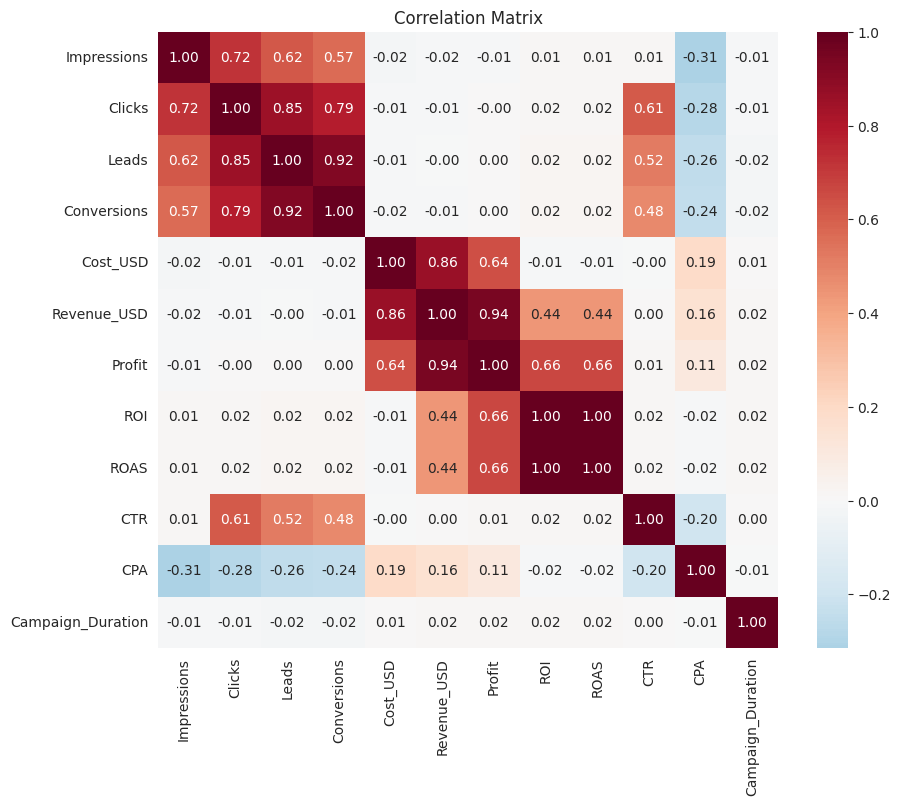

In [ ]:
corr_cols = [
    "Impressions",
    "Clicks",
    "Leads",
    "Conversions",
    "Cost_USD",
    "Revenue_USD",
    "Profit",
    "ROI",
    "ROAS",
    "CTR",
    "CPA",
    "Campaign_Duration"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Insight

The correlation matrix reveals several strong relationships among marketing metrics, highlighting how customer engagement and financial performance are interconnected throughout the marketing funnel.
The strongest positive correlation is observed between Revenue and Profit (r = 0.94), indicating that campaigns generating higher revenue also tend to produce higher profit. This suggests that revenue growth remains a key driver of overall campaign profitability.
Another strong relationship exists between Leads and Conversions (r = 0.92), demonstrating that generating qualified leads is highly associated with increasing successful conversions. Additionally, Campaign Cost and Revenue (r = 0.86) show a strong positive correlation, suggesting that higher marketing investment generally leads to greater revenue generation.
Within the marketing funnel, Clicks and Leads (r = 0.85) and Clicks and Conversions (r = 0.79) also exhibit strong positive relationships, indicating that user engagement plays an important role in driving downstream conversion outcomes.
Conversely, Campaign Duration shows almost no meaningful correlation with other variables, suggesting that extending campaign duration alone does not significantly improve marketing performance.

Business Impact

The findings suggest that campaign success depends more on the quality of customer acquisition and conversion efficiency than on campaign duration or increased spending alone. While higher marketing investment contributes to greater revenue, maximizing profit ultimately requires improving lead quality and conversion effectiveness throughout the customer journey.

Recommendation

Prioritize strategies that improve lead generation and conversion quality, as these metrics demonstrate the strongest influence on campaign success.
Continue investing in campaigns with proven revenue potential while monitoring profitability metrics such as Profit, ROI, and ROAS to ensure efficient budget utilization.
Optimize the marketing funnel by improving click-through quality, landing page experience, and conversion processes rather than simply increasing campaign duration or marketing expenditure.
Regularly monitor correlation trends to identify changes in campaign performance and support data-driven budget allocation decisions.

### Does higher marketing spending lead to higher revenue?

In [ ]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df["Cost_USD"], df["Revenue_USD"])

print(f"Correlation : {corr:.3f}")
print(f"P-value     : {p_value:.5f}")

Correlation : 0.860
P-value     : 0.00000


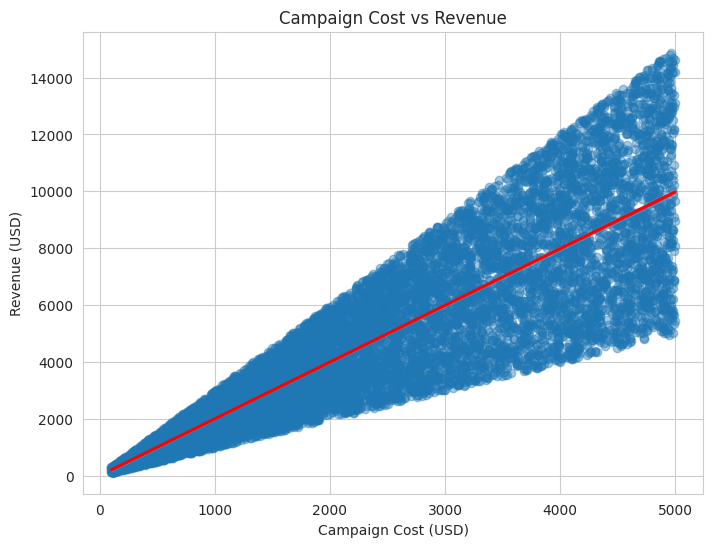

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Cost_USD",
    y="Revenue_USD",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.title("Campaign Cost vs Revenue")

plt.xlabel("Campaign Cost (USD)")
plt.ylabel("Revenue (USD)")

plt.show()

Insight

Campaign cost and revenue exhibit a strong positive correlation (r = 0.86, p = 0.00), indicating that campaigns with higher marketing investment generally generate higher revenue.

Impact

Marketing budget is a key driver of revenue generation. However, higher spending alone does not guarantee better marketing efficiency or profitability, making it important to evaluate additional performance metrics such as ROI, ROAS, and Profit.

Recommendation

Continue investing in campaigns with higher revenue potential while monitoring ROI and profitability to ensure additional spending produces proportional business value.

### Does higher spending always produce higher ROI?

In [ ]:
corr, p_value = pearsonr(df["Cost_USD"], df["ROI"])

print(f"Correlation : {corr:.3f}")
print(f"P-value     : {p_value:.3f}")

Correlation : -0.007
P-value     : 0.472


Insight

Campaign Cost and ROI show virtually no correlation (r = -0.007, p = 0.472).
The p-value far exceeds the 0.05 significance threshold, confirming that this
near-zero relationship is not statistically significant — it is consistent
with random noise rather than a real pattern.

Impact

This indicates that increasing marketing spend does not, on its own, improve
investment efficiency. A campaign with a small budget can achieve an ROI just
as strong as one with a much larger budget, since ROI appears to be driven by
factors other than spending level.

Recommendation

Avoid using budget size as a lever for improving ROI. Instead, focus on
factors within campaign execution — audience targeting, creative quality,
and channel selection — which are more likely to drive efficiency gains than
simply spending more.

### Do more leads result in more conversions?

In [ ]:
corr, p_value = pearsonr(df["Leads"], df["Conversions"])

print(f"Correlation : {corr:.3f}")
print(f"P-value     : {p_value:.5f}")

Correlation : 0.920
P-value     : 0.00000


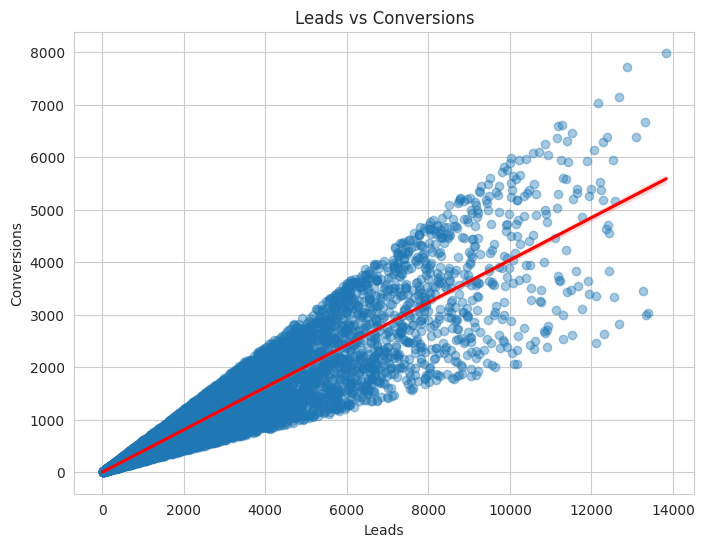

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Leads",
    y="Conversions",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.title("Leads vs Conversions")

plt.show()

Insight

Leads and conversions exhibit a strong positive relationship, indicating that campaigns generating more qualified leads tend to achieve higher conversion volumes. This suggests that improving lead generation directly supports conversion performance.

Impact

Lead generation is one of the strongest drivers of campaign success. Enhancing lead quality can significantly increase customer conversions without necessarily increasing overall marketing expenditure.

Recommendation

Invest in audience targeting, lead nurturing, and personalized marketing strategies to improve lead quality and maximize conversion outcomes.

### Do more clicks generate more leads?

In [ ]:
corr, p_value = pearsonr(df["Clicks"], df["Leads"])

print(f"Correlation : {corr:.3f}")
print(f"P-value     : {p_value:.5f}")

Correlation : 0.852
P-value     : 0.00000


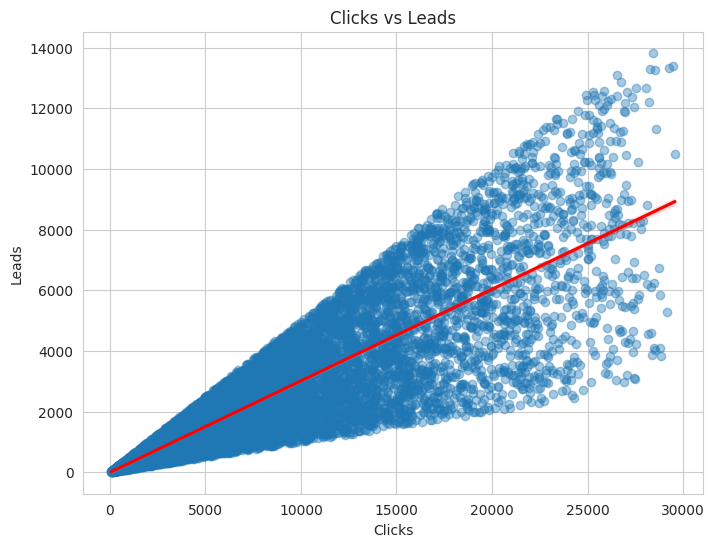

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Clicks",
    y="Leads",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.title("Clicks vs Leads")

plt.show()

Insight

Clicks and leads demonstrate a strong positive relationship, suggesting that campaigns attracting more user engagement are more likely to generate potential customers.

Impact

Improving click performance can strengthen the upper stages of the marketing funnel, ultimately contributing to higher lead generation and downstream conversions.

Recommendation

Optimize ad creatives, audience targeting, and call-to-action elements to increase click quality while ensuring landing pages effectively convert visitors into leads.

## Statistical Significance Testing

In [ ]:
!pip install scikit-posthocs -q

In [ ]:
from scipy.stats import levene, f_oneway

In [ ]:
import scikit_posthocs as sp

metrics_to_test = ["Revenue_USD", "ROI", "CPA"]
channels = df["Channel"].unique()

for metric in metrics_to_test:
    groups = [df[df["Channel"] == ch][metric].dropna() for ch in channels]
    stat, p = levene(*groups)
    print(f"{metric:12s} | Levene's Test p-value: {p:.5f} -> {'Variance homogen' if p > 0.05 else 'Variance TIDAK homogen'}")

Revenue_USD  | Levene's Test p-value: 0.66469 -> Variance homogen
ROI          | Levene's Test p-value: 0.63840 -> Variance homogen
CPA          | Levene's Test p-value: 0.39108 -> Variance homogen


In [ ]:
anova_results = []

for metric in metrics_to_test:
    groups = [df[df["Channel"] == ch][metric].dropna() for ch in channels]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({"Metric": metric, "F-statistic": round(f_stat, 3), "p-value": round(p_val, 5)})

anova_df = pd.DataFrame(anova_results)
anova_df

,Metric,F-statistic,p-value
0,Revenue_USD,1.168,0.32260
1,ROI,0.612,0.65385
2,CPA,1.043,0.38308


Insight

Levene's Test confirmed homogeneous variance across channels for all three
metrics (p > 0.05), satisfying the assumption required for ANOVA. However,
one-way ANOVA results show that the differences observed between channels
are not statistically significant: Revenue_USD (F = 1.168, p = 0.323),
ROI (F = 0.612, p = 0.654), and CPA (F = 1.043, p = 0.383) all exceed the
0.05 significance threshold.

Impact

This means the channel-level differences identified earlier — such as
Display's higher average revenue or Search's higher average ROI — cannot be
confirmed as statistically real effects at the 95% confidence level. They
may reflect genuine but modest performance gaps, or simply random variation
in the data. Since ANOVA found no significant differences, no post-hoc
testing is needed.

Recommendation

Treat the channel-level differences identified throughout this analysis as
directional signals rather than statistically confirmed effects. Avoid
making large, irreversible budget reallocations based on these differences
alone. Instead, use them to guide smaller-scale testing (e.g., A/B budget
shifts) and continue monitoring performance over a longer time period or
larger sample to confirm whether these patterns hold statistically.

# Business Insight & Recomendation

## Key Findings

**Finding 1: Display leads in absolute revenue and profit, while Search leads in efficiency — but these differences are not statistically significant**

Display campaigns show the highest average Revenue (USD 5,178.89) and Profit
(USD 2,596.39), while Search shows the highest average ROI (101.33%) and
ROAS (2.01). However, one-way ANOVA testing found no statistically
significant difference in Revenue (p = 0.323), ROI (p = 0.654), or CPA
(p = 0.383) across the five channels. These patterns should therefore be
treated as directional signals rather than confirmed performance gaps.

**Finding 2: Influencer campaigns show the lowest average customer acquisition cost**

Influencer campaigns recorded the lowest average CPA (USD 9.11). As with
Finding 1, ANOVA testing found this difference is not statistically
significant (p = 0.383), so it should be treated as a modest, unconfirmed
advantage rather than a proven cost efficiency.

**Finding 3: Funnel-stage metrics (CTR, Conversion Rate) do not meaningfully differ by channel**

CTR ranges narrowly from 5.43% to 5.52%, and Conversion Rate from 40.09% to
40.28% across all five channels — differences too small to be practically
or statistically meaningful. Channel choice does not appear to influence
click or conversion behavior.

**Finding 4: Campaign spending drives revenue, but not efficiency or duration**

Campaign Cost and Revenue show a strong, statistically significant positive
correlation (r = 0.86, p < 0.001). However, Cost shows virtually no
relationship with ROI (r = -0.007, p = 0.472), and Campaign Duration shows
virtually no relationship with Revenue (r = 0.015, p = 0.125). Spending
more or running campaigns longer does not, by itself, improve financial
return.

**Finding 5: Marketing funnel stages reinforce each other**

Leads and Conversions show a strong positive relationship, as do Clicks and
Leads, indicating that improvements at the top of the funnel consistently
carry through to leads and conversions rather than leaking out at any
single stage.

## Strategic Recommendations

**Recommendation 1: Use channel-level differences as directional signals, not confirmed effects**

Since ANOVA testing found no statistically significant difference in
Revenue, ROI, or CPA across channels, avoid large, irreversible budget
reallocations based on current averages alone. Use small-scale A/B budget
tests to validate whether Display, Search, and Influencer's apparent
advantages hold up under controlled comparison.

**Recommendation 2: Use Search's efficiency profile as a benchmark for campaign optimization**

While not statistically confirmed as superior, Search's higher ROI and
ROAS make it a reasonable benchmark for targeting, creative, and audience
strategy when optimizing other channels — particularly Display, which
shows strong revenue but slightly lower efficiency.

**Recommendation 3: Test Influencer campaign expansion at a controlled scale**

Influencer's lower CPA is a promising but unconfirmed signal. Expand
Influencer investment incrementally and monitor whether acquisition cost
and customer quality remain favorable at greater scale, rather than
committing a large budget shift upfront.

**Recommendation 4: Do not use CTR, Conversion Rate, or campaign duration as budget-allocation levers**

These metrics show no meaningful variation by channel and no significant
correlation with financial outcomes. Focus optimization efforts on
targeting and creative quality instead.

**Recommendation 5: Adopt a multi-KPI, statistically-grounded evaluation framework**

Continue evaluating campaigns using a combination of Revenue, Profit, ROI,
ROAS, and CPA — but pair channel comparisons with significance testing
(ANOVA or equivalent) before treating any channel as a confirmed top or
bottom performer, given the modest sample-level differences found in this
analysis.

## Conclusion

This analysis evaluated marketing campaign performance across five channels
by examining revenue, profitability, efficiency, and customer acquisition
metrics. Display shows the highest absolute revenue and profit, Search
shows the highest investment efficiency, and Influencer shows the lowest
acquisition cost — but statistical testing (one-way ANOVA) found none of
these channel-level differences to be significant at the 95% confidence
level. Funnel-stage metrics such as CTR and Conversion Rate showed minimal
variation across channels, and neither campaign spending nor campaign
duration meaningfully improved ROI. These results suggest that, within the
current dataset, channel choice has less influence on performance than
often assumed — execution quality and targeting are more likely drivers of
outcomes. Future decisions should treat channel-level patterns as
hypotheses to test at scale, rather than confirmed drivers of performance.